# 2-4. 상관분석

일별 금값, 은값, 달러 환율 사이의 선형 관계를 확인한다.

- 피어슨 상관분석으로 두 연속형 변수 사이의 선형 관계를 검정한다.
- 상관관계는 함께 변하는 정도를 보여줄 뿐, 인과관계를 의미하지는 않는다.

In [1]:
import numpy as np
import pandas as pd
from scipy import stats
from matplotlib import pyplot as plt

# macOS 한글 폰트를 그래프 기본 글꼴로 설정한다.
plt.rcParams["font.family"] = "Apple SD Gothic Neo"
plt.rcParams["axes.unicode_minus"] = False

# 일별 금값, 은값, 달러 환율 데이터를 읽는다.
prices_df = pd.read_excel("datas2/일별_금은달러.xlsx")

# 데이터 일부와 열 이름을 확인한다.
print(prices_df.head())
print(prices_df.columns)

           일자        금값     은값   달러 환율
0  2020.08.07  78538.90  27.53  1188.5
1  2020.08.06  78009.22  28.39  1185.5
2  2020.08.05  77748.00  26.88  1188.0
3  2020.08.04  75873.57  26.01  1194.5
4  2020.08.03  75761.76  24.39  1195.7
Index(['일자', '금값', '은값', '달러 환율'], dtype='str')


## 1. 상관분석 데이터 확인

금값, 은값, 달러 환율은 모두 연속형 수치 데이터다.
상관분석 전에 결측값이 있는지와 각 변수의 범위를 확인한다.

In [2]:
# 상관분석에 사용할 수치형 열만 선택한다.
price_columns = ["금값", "은값", "달러 환율"]
price_data = prices_df[price_columns]

# 결측값 개수와 기초 통계량을 확인한다.
print("열별 결측값 개수")
print(price_data.isna().sum())

print("\n기초 통계량")
print(price_data.describe().round(2))

열별 결측값 개수
금값       0
은값       0
달러 환율    0
dtype: int64

기초 통계량
             금값     은값    달러 환율
count     28.00  28.00    28.00
mean   72081.84  21.83  1197.72
std     3309.33   3.14     5.46
min    68269.27  18.13  1185.50
25%    69744.95  19.06  1194.88
50%    70117.34  20.81  1197.00
75%    75110.48  24.28  1203.00
max    78538.90  28.39  1206.50


## 2. 산점도로 관계 확인

피어슨 상관계수는 두 변수의 선형 관계를 측정한다.
검정 전에 산점도를 보고 관계의 방향과 선형성을 확인한다.

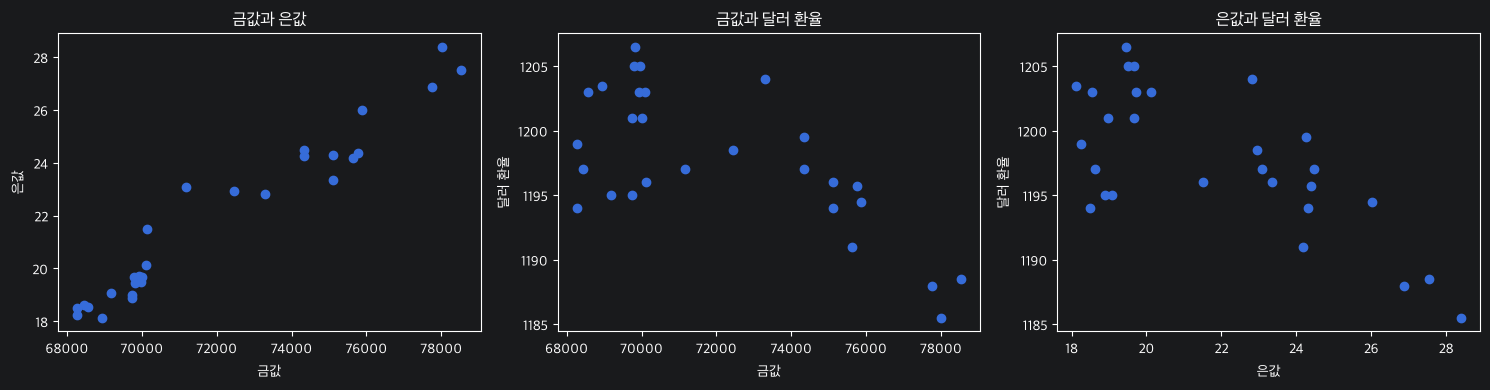

In [3]:
# 비교할 변수 쌍과 그래프 제목을 정의한다.
pairs = [
    ("금값", "은값", "금값과 은값"),
    ("금값", "달러 환율", "금값과 달러 환율"),
    ("은값", "달러 환율", "은값과 달러 환율")
]

# 세 변수 쌍의 산점도를 한 줄에 그린다.
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for axis, (x_column, y_column, title) in zip(axes, pairs):
    axis.scatter(prices_df[x_column], prices_df[y_column])
    axis.set_xlabel(x_column)
    axis.set_ylabel(y_column)
    axis.set_title(title)

plt.tight_layout()
plt.show()

## 3. 피어슨 상관분석

각 변수 쌍의 선형 상관관계를 검정한다.

- 귀무가설(H₀): 두 변수의 모집단 상관계수는 0이다. 즉, 선형 관계가 없다.
- 대립가설(H₁): 두 변수의 모집단 상관계수는 0이 아니다.

In [4]:
# 각 변수 쌍에 피어슨 상관분석을 수행한다.
pearson_results = []

for x_column, y_column, _ in pairs:
    result = stats.pearsonr(
        prices_df[x_column],
        prices_df[y_column]
    )

    pearson_results.append({
        "비교": f"{x_column} - {y_column}",
        "피어슨 상관계수": result.statistic,
        "p-value": result.pvalue
    })

# 상관계수와 p-value를 표로 정리한다.
pearson_summary = pd.DataFrame(pearson_results)

# p-value가 0.05 이하인지로 통계적 유의성을 표시한다.
pearson_summary["유의한 선형 관계"] = pearson_summary["p-value"] <= 0.05

pearson_summary.round(4)

,비교,피어슨 상관계수,p-value,유의한 선형 관계
0,금값 - 은값,0.9719,0.0000,True
1,금값 - 달러 환율,-0.6793,0.0001,True
2,은값 - 달러 환율,-0.6955,0.0000,True


## 4. 스피어만 상관분석

스피어만 상관계수는 실제 값 대신 각 값의 순위를 사용해 관계를 측정한다.

- 값이 일정하게 증가하거나 감소하는 단조 관계를 확인할 수 있다.
- 이상치의 영향을 피어슨 상관계수보다 덜 받는다.

In [5]:
# 각 변수 쌍에 스피어만 상관분석을 수행한다.
spearman_results = []

for x_column, y_column, _ in pairs:
    result = stats.spearmanr(
        prices_df[x_column],
        prices_df[y_column]
    )

    spearman_results.append({
        "비교": f"{x_column} - {y_column}",
        "스피어만 상관계수": result.statistic,
        "p-value": result.pvalue
    })

# 스피어만 상관계수와 p-value를 표로 정리한다.
spearman_summary = pd.DataFrame(spearman_results)
spearman_summary["유의한 단조 관계"] = spearman_summary["p-value"] <= 0.05

spearman_summary.round(4)

,비교,스피어만 상관계수,p-value,유의한 단조 관계
0,금값 - 은값,0.9711,0.0000,True
1,금값 - 달러 환율,-0.5039,0.0063,True
2,은값 - 달러 환율,-0.5281,0.0039,True


In [6]:
# 피어슨 상관계수 행렬을 계산한다.
pearson_matrix = price_data.corr(method="pearson")

# 스피어만 상관계수 행렬을 계산한다.
spearman_matrix = price_data.corr(method="spearman")

print("피어슨 상관계수 행렬")
print(pearson_matrix.round(4))

print("\n스피어만 상관계수 행렬")
print(spearman_matrix.round(4))

피어슨 상관계수 행렬
           금값      은값   달러 환율
금값     1.0000  0.9719 -0.6793
은값     0.9719  1.0000 -0.6955
달러 환율 -0.6793 -0.6955  1.0000

스피어만 상관계수 행렬
           금값      은값   달러 환율
금값     1.0000  0.9711 -0.5039
은값     0.9711  1.0000 -0.5281
달러 환율 -0.5039 -0.5281  1.0000


## 5. 분석 결과

- 금값과 은값은 피어슨 상관계수 0.9719로, 매우 강한 양의 선형 관계를 보였다.
- 금값과 달러 환율은 피어슨 상관계수 -0.6793으로, 유의한 음의 선형 관계를 보였다.
- 은값과 달러 환율은 피어슨 상관계수 -0.6955로, 유의한 음의 선형 관계를 보였다.
- 스피어만 상관분석에서도 세 관계의 방향과 유의성이 동일하게 확인됐다.
- 다만 상관관계는 두 변수가 함께 변한 정도를 보여줄 뿐, 한 변수가 다른 변수를 직접 변화시켰다는 인과관계를 뜻하지는 않는다.
- 또한 세 변수는 같은 기간의 시계열 데이터이므로, 공통된 시간 흐름이나 외부 요인이 상관관계에 영향을 주었을 수 있다.